## EDA Student Performance

### ML Project Lifecycle

- Understanding problem statement
- Data collection
- Data Checks
- Data Preprocessing
- Model Training
- Choose best model

In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
# import data as pandas dataframe
df = pd.read_csv("data/stud.csv")

In [9]:
# Show top 5 records
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
# Shape of data
df.shape

(1000, 8)

In [11]:
# Describe data
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [16]:
categorical_features = [col for col in df.columns if df[col].dtype == "O"]
numerical_features = [col for col in df.columns if df[col].dtype != "O"]

print("There are {} categorical features".format(len(categorical_features)))
print("There are {} numerical features".format(len(numerical_features)))

There are 5 categorical features
There are 3 numerical features


In [25]:
# unique categories in categorical features
for col in categorical_features:
    print(f"{col} has {len(df[col].unique())} unique categories : {df[col].unique()}")

gender has 2 unique categories : ['female' 'male']
race_ethnicity has 5 unique categories : ['group B' 'group C' 'group A' 'group D' 'group E']
parental_level_of_education has 6 unique categories : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch has 2 unique categories : ['standard' 'free/reduced']
test_preparation_course has 2 unique categories : ['none' 'completed']


In [29]:
maths_full = df[df["math_score"]==100]
reading_full = df[df["reading_score"]==100]
writing_full = df[df["writing_score"]==100]

In [31]:
print(f"Number of students with full marks in Maths : {len(maths_full)}")
print(f"Number of students with full marks in reading : {len(reading_full)}")
print(f"Number of students with full marks in writing : {len(writing_full)}")

Number of students with full marks in Maths : 7
Number of students with full marks in reading : 17
Number of students with full marks in writing : 14


In [35]:
reading_less_20 = df[df["reading_score"]<=20]
writing_less_20 = df[df["writing_score"]<=20]
math_less_20 = df[df["math_score"]<=20]

print(f"Number of students with less than 20 in Maths : {len(math_less_20)}")
print(f"Number of students with less than 20 in Reading : {len(reading_less_20)}")
print(f"Number of students with less than 20 in Writing : {len(writing_less_20)}")

Number of students with less than 20 in Maths : 4
Number of students with less than 20 in Reading : 1
Number of students with less than 20 in Writing : 3


In [40]:
# get total and avg scores
df_copy = df.copy()

df_copy["total_score"] = df["math_score"]+df["reading_score"]+df["writing_score"]
df_copy["avg_score"] = round(df_copy["total_score"]/3,2)


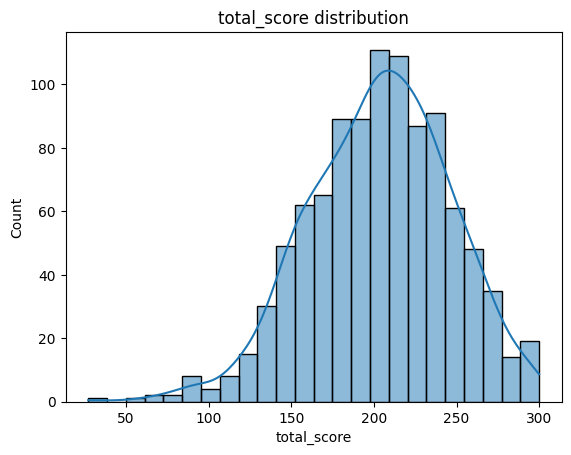

In [44]:
sns.histplot(df_copy["total_score"], kde=True)
plt.title("total_score distribution")
plt.show()

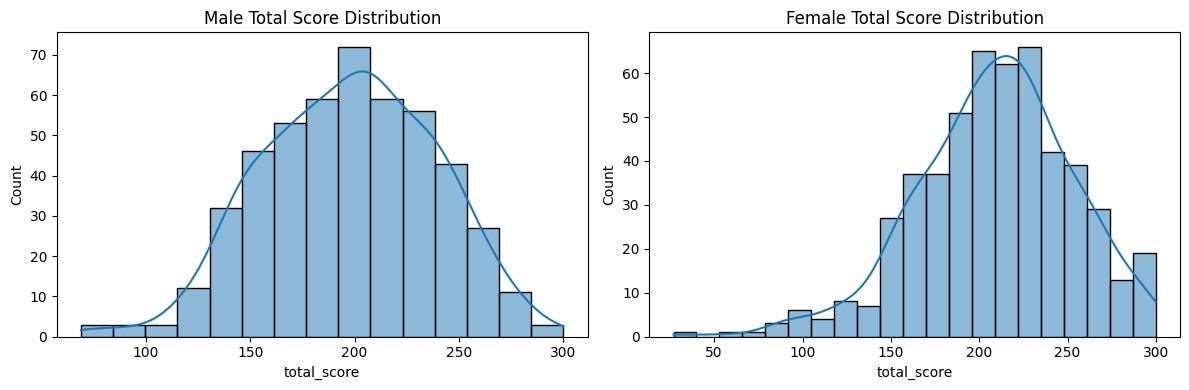

In [59]:
male_df = df_copy[df_copy["gender"]=="male"]
female_df = df_copy[df_copy["gender"]=="female"]


fig, axs = plt.subplots(1,2, figsize=(12,4))
axs = axs.ravel()

sns.histplot(data=male_df, x="total_score",kde=True, ax=axs[0])
axs[0].set_title("Male Total Score Distribution")

sns.histplot(data=female_df, x = "total_score", kde=True, ax=axs[1])
axs[1].set_title("Female Total Score Distribution")

plt.tight_layout()
plt.show()

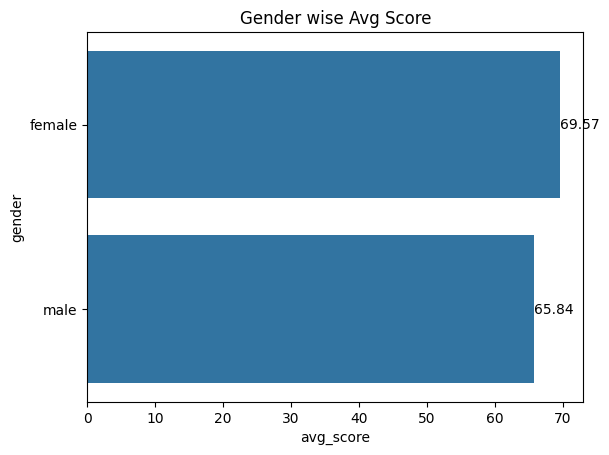

In [66]:
ax = sns.barplot(data=df_copy, y=df_copy["gender"], x=df_copy["avg_score"], ci=None)
ax.set_title("Gender wise Avg Score")

for container in ax.containers:
    ax.bar_label(container=container, fmt="%.2f")

plt.show()

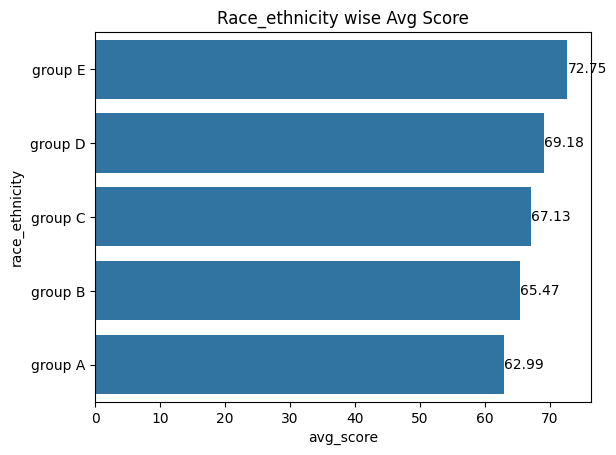

In [78]:
df_sorted = df_copy.groupby("race_ethnicity", as_index=False)["avg_score"].mean().round(2)
df_sorted = df_sorted.sort_values("avg_score", ascending=False)

ax = sns.barplot(data=df_sorted, y="race_ethnicity", x="avg_score", ci=None)
ax.set_title("Race_ethnicity wise Avg Score")

for container in ax.containers:
    ax.bar_label(container=container, fmt="%.2f")

plt.show()

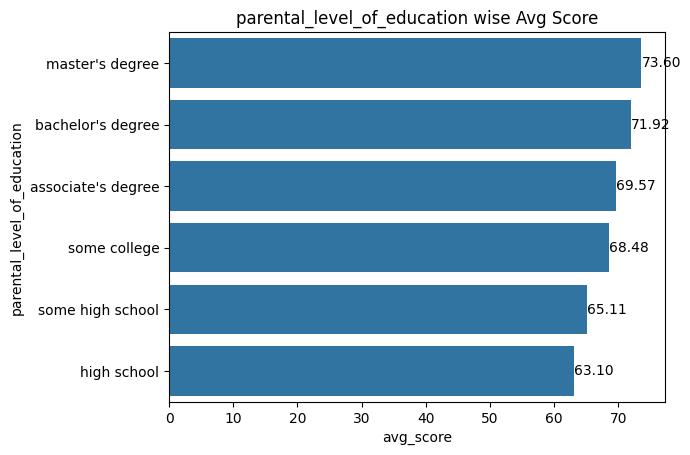

In [82]:
df_sorted = df_copy.groupby("parental_level_of_education", as_index=False)["avg_score"].mean().round(2)
df_sorted = df_sorted.sort_values("avg_score", ascending=False)

ax = sns.barplot(data=df_sorted, y="parental_level_of_education", x="avg_score", ci=None)
ax.set_title("parental_level_of_education wise Avg Score")

for container in ax.containers:
    ax.bar_label(container=container, fmt="%.2f")

plt.show()

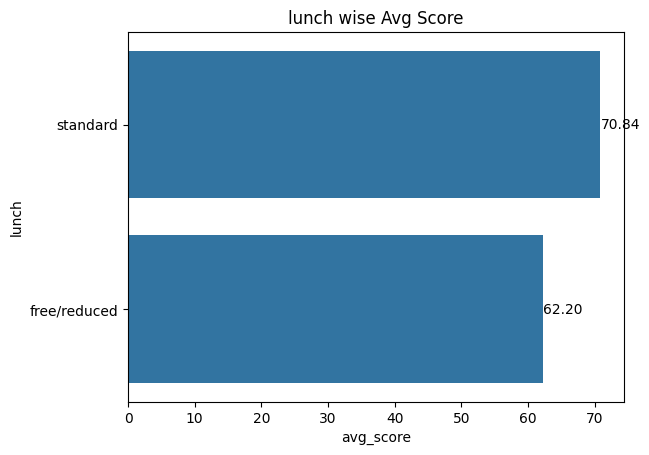

In [83]:
df_sorted = df_copy.groupby("lunch", as_index=False)["avg_score"].mean().round(2)
df_sorted = df_sorted.sort_values("lunch", ascending=False)

ax = sns.barplot(data=df_sorted, y="lunch", x="avg_score", ci=None)
ax.set_title("lunch wise Avg Score")

for container in ax.containers:
    ax.bar_label(container=container, fmt="%.2f")

plt.show()

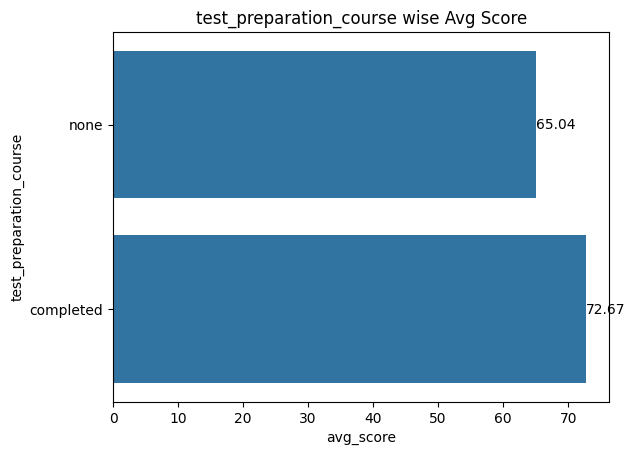

In [85]:
df_sorted = df_copy.groupby("test_preparation_course", as_index=False)["avg_score"].mean().round(2)
df_sorted = df_sorted.sort_values("test_preparation_course", ascending=False)

ax = sns.barplot(data=df_sorted, y="test_preparation_course", x="avg_score", ci=None)
ax.set_title("test_preparation_course wise Avg Score")

for container in ax.containers:
    ax.bar_label(container=container, fmt="%.2f")

plt.show()

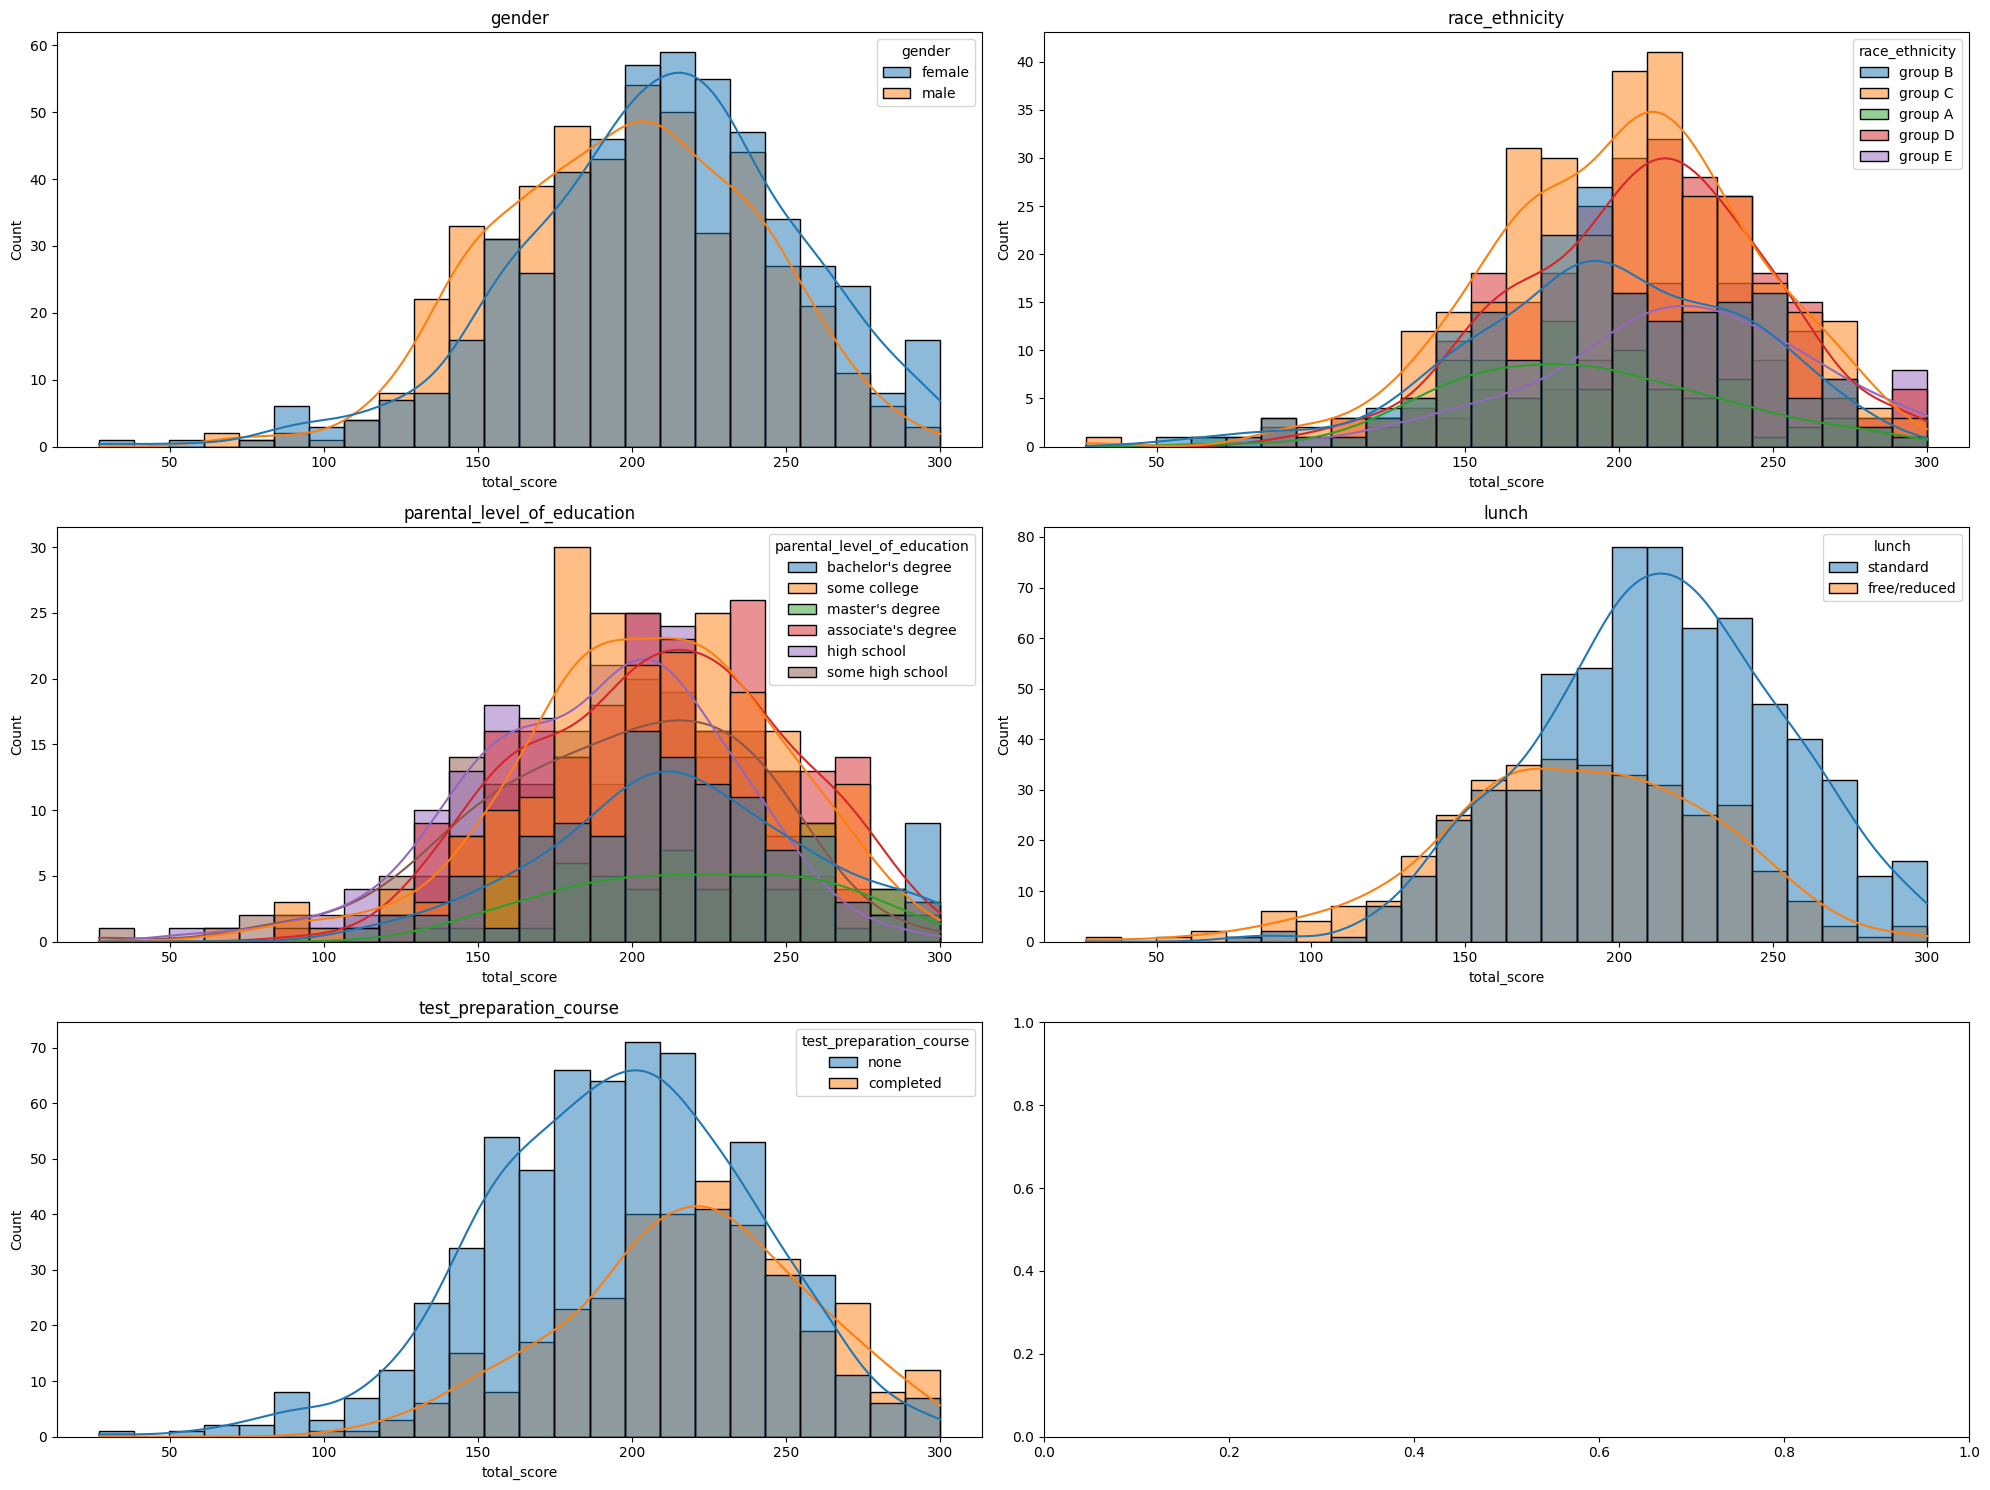

In [ ]:
# total score distribution by all categories
rows = 3
col = 2

fig, axs = plt.subplots(3,2, figsize=(20,15))
axs = axs.ravel()
for col, i in zip(categorical_features, range(rows*col)):
    sns.histplot(data=df_copy, x = "total_score", hue=col, kde=True, ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

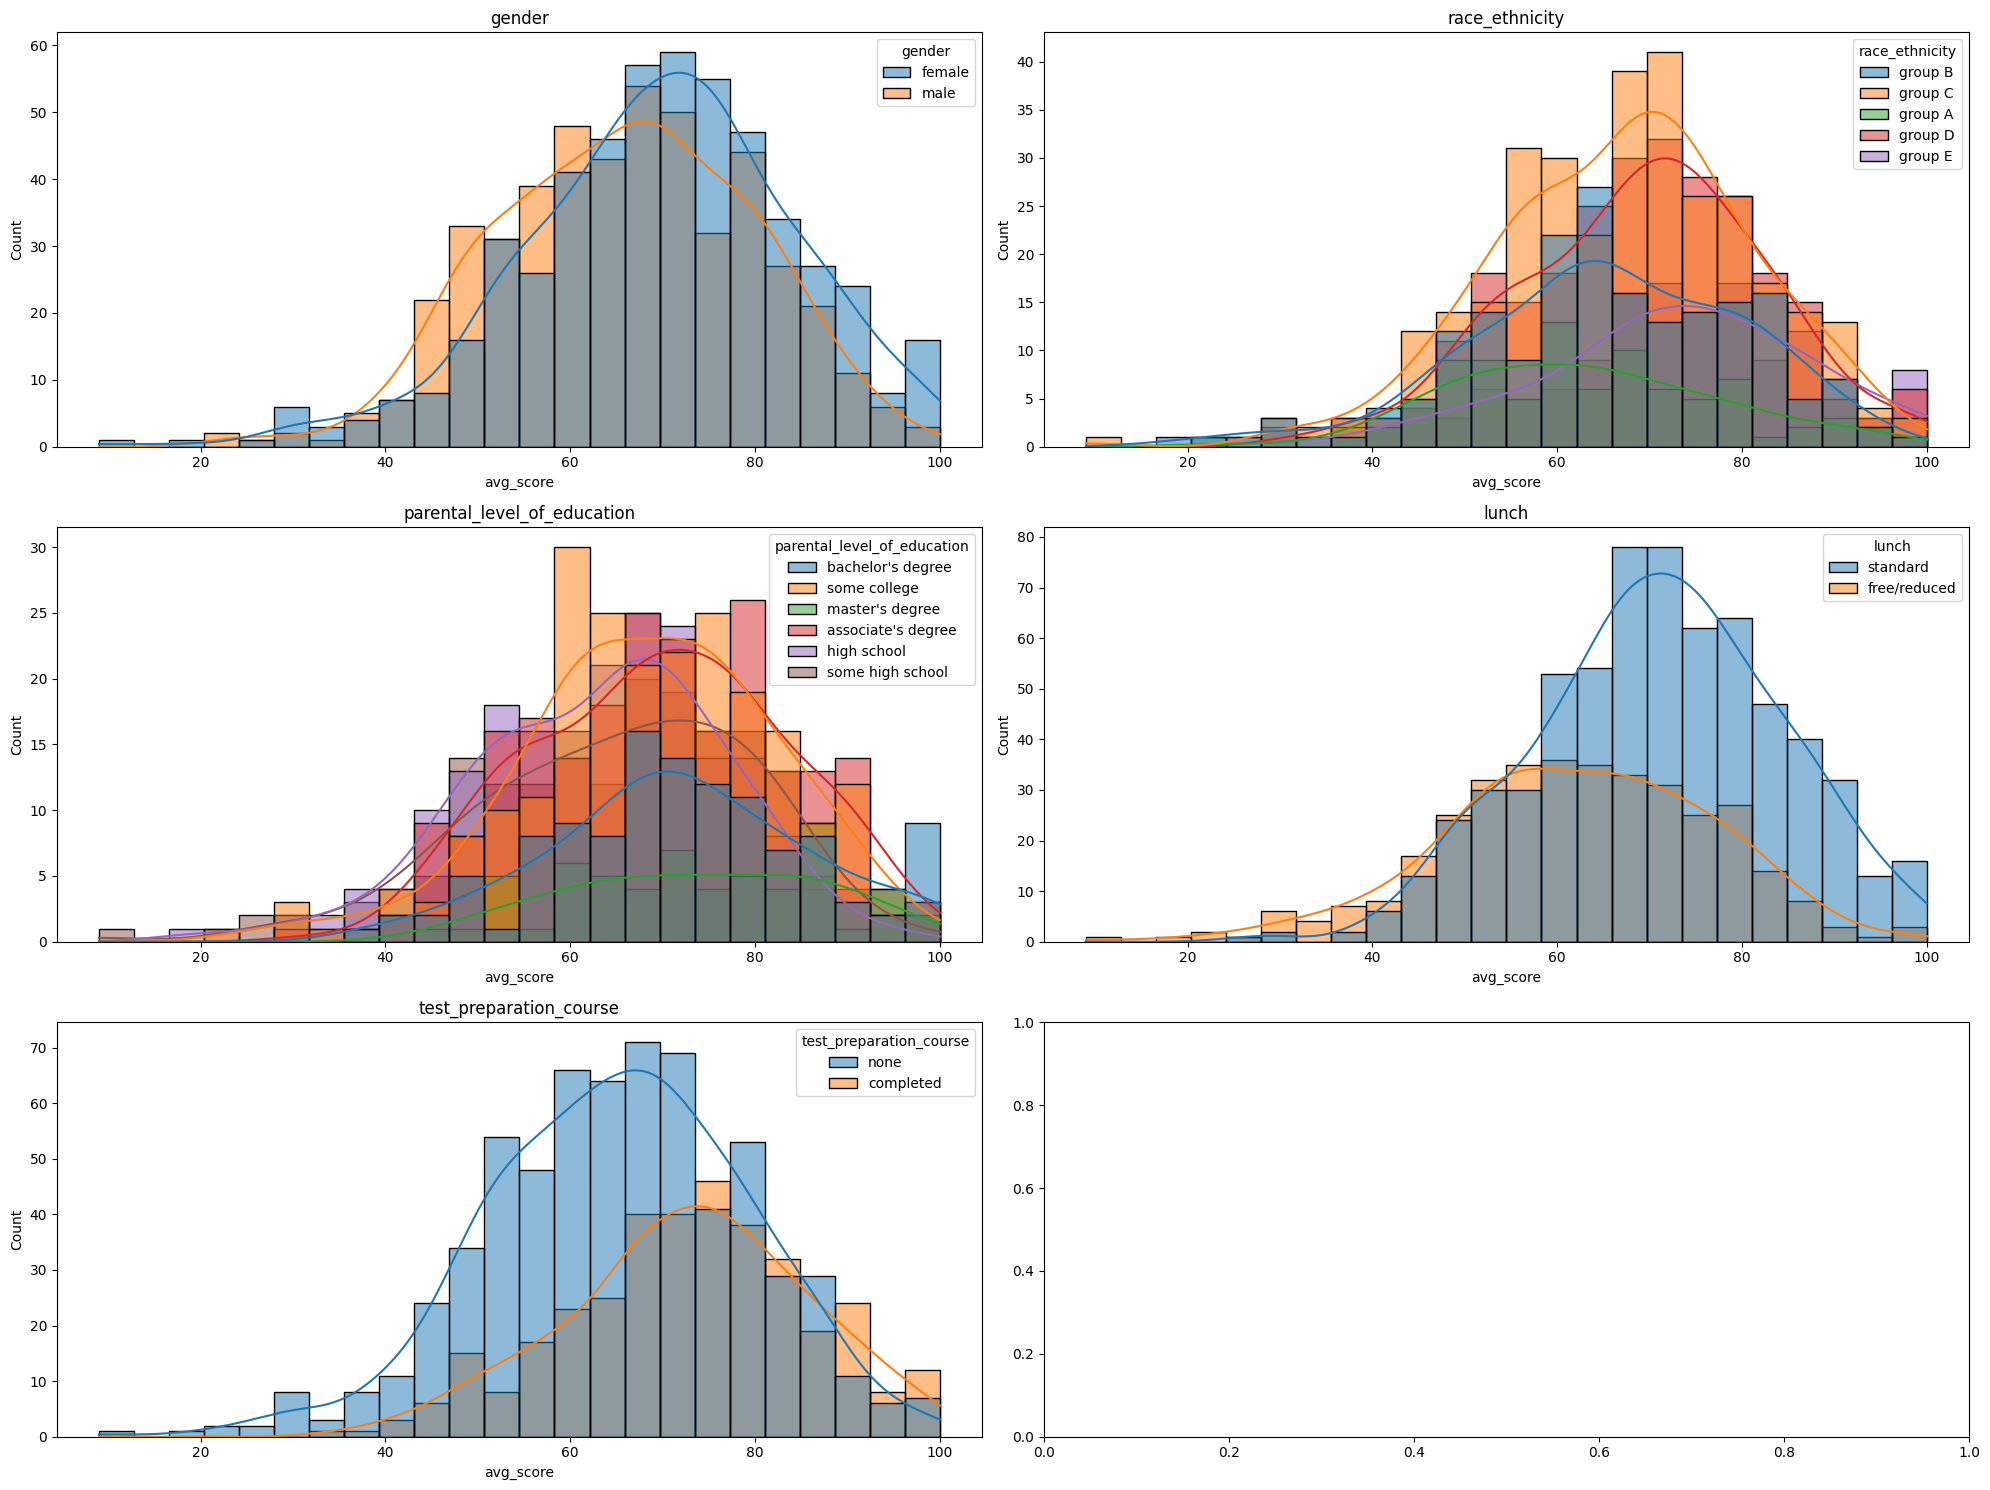

In [100]:
# avg score distribution by all categories
rows = 3
col = 2

fig, axs = plt.subplots(3,2, figsize=(20,15))
axs = axs.ravel()
for col, i in zip(categorical_features, range(rows*col)):
    sns.histplot(data=df_copy, x = "avg_score", hue=col, kde=True, ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()